# STAT 207: Permutation Tests and the Bootstrap

**NAS Chapter 24**

Permutation tests and the bootstrap replace fragile analytic approximations with resampling.

- Both methods resample the observed data and reduce reliance on dubious model assumptions or large-sample theory.
- **Permutation tests** target hypothesis testing under an exchangeability/randomization null.
- The **bootstrap** studies the sampling behavior of an estimator by replacing the unknown distribution $F$ with a data-based approximation.
- The chapter is practical in spirit: exact enumeration when possible, Monte Carlo approximation when needed, and repeated simulation until the inferential conclusions stabilize.


## 24.1 Introduction

- Fisher's permutation ideas (1935) connect naturally to randomized experiments and small-sample inference.
-  **Population sampling** versus **randomization**: in many applications the sample itself is not random, but treatment labels are randomized to guard against hidden bias.
- Permutation tests rely more on **computation** than elegant asymptotics, but they are easy to explain and can be nearly as powerful as classical parametric tests.
- The bootstrap inherits the resampling philosophy of the jackknife while giving direct access to standard errors, bias estimates, and confidence intervals.


## 24.2 Permutation Tests

- For two samples $x_1,\ldots,x_m$ and $y_1,\ldots,y_n$, a natural statistic is
$$
T = \bar x - \bar y.
$$
- Under the null hypothesis that the pooled observations are **exchangeable**, every split of the pooled sample into groups of sizes $m$ and $n$ is equally plausible.
- The exact p-value is
$$
p = \Pr\left(|T^\pi| \ge |T_{\text{obs}}| \mid z\right),
$$
where $T^\pi$ is computed after permuting the pooled data vector $z$.
- If $\binom{m+n}{m}$ is too large, Monte Carlo permutations approximate the exact p-value, with standard error roughly $\sqrt{p(1-p)/B}$.


Wing length p-value (exact): 0.0719
Antenna length p-value (exact): 0.0022


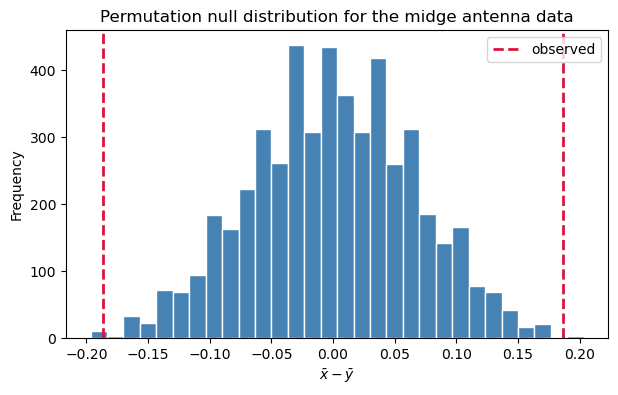

In [ ]:
import math
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

rng = np.random.default_rng(207)


def diff_in_means(x, y):
    return np.mean(x) - np.mean(y)


def split_by_sizes(values, sizes):
    cuts = np.cumsum(sizes)[:-1]
    return np.split(values, cuts)


def permutation_test(x, y, statistic=diff_in_means, n_resamples=50_000, rng=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.concatenate([x, y])
    m = len(x)
    observed = statistic(x, y)
    total = math.comb(len(z), m)

    if total <= n_resamples:
        null_stats = []
        for idx in combinations(range(len(z)), m):
            mask = np.zeros(len(z), dtype=bool)
            mask[list(idx)] = True
            null_stats.append(statistic(z[mask], z[~mask]))
        null_stats = np.array(null_stats)
        p_value = np.mean(np.abs(null_stats) >= abs(observed))
        mode = "exact"
        mc_interval = None
    else:
        if rng is None:
            rng = np.random.default_rng()
        null_stats = np.empty(n_resamples)
        for b in range(n_resamples):
            permuted = rng.permutation(z)
            null_stats[b] = statistic(permuted[:m], permuted[m:])
        p_value = np.mean(np.abs(null_stats) >= abs(observed))
        se = np.sqrt(p_value * (1 - p_value) / n_resamples)
        mc_interval = (max(0.0, p_value - 1.96 * se), min(1.0, p_value + 1.96 * se))
        mode = "monte_carlo"

    return {
        "observed": observed,
        "p_value": p_value,
        "mode": mode,
        "null_stats": null_stats,
        "mc_interval": mc_interval,
    }



In [ ]:

# Table 24.1: midge morphology data from the chapter.
wing_a = np.array([1.72, 1.64, 1.74, 1.70, 1.82, 1.82, 1.90, 1.82, 2.08])
antenna_a = np.array([1.24, 1.38, 1.36, 1.40, 1.38, 1.48, 1.38, 1.54, 1.56])
wing_b = np.array([1.78, 1.86, 1.96, 2.00, 2.00, 1.96])
antenna_b = np.array([1.14, 1.20, 1.30, 1.26, 1.28, 1.18])

wing_result = permutation_test(wing_a, wing_b, n_resamples=100_000, rng=rng)
antenna_result = permutation_test(antenna_a, antenna_b, n_resamples=100_000, rng=rng)

print(f"Wing length p-value ({wing_result['mode']}): {wing_result['p_value']:.4f}")
print(f"Antenna length p-value ({antenna_result['mode']}): {antenna_result['p_value']:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(antenna_result["null_stats"], bins=30, color="steelblue", edgecolor="white")
ax.axvline(antenna_result["observed"], color="crimson", linestyle="--", linewidth=2, label="observed")
ax.axvline(-antenna_result["observed"], color="crimson", linestyle="--", linewidth=2)
ax.set_title("Permutation null distribution for the midge antenna data")
ax.set_xlabel(r"$\bar{x} - \bar{y}$")
ax.set_ylabel("Frequency")
ax.legend()
plt.show()


### Additional Examples

- **One-way layout**: with group sizes $n_1,\ldots,n_k$, the chapter uses the statistic
$$
S = \sum_{i=1}^k n_i \bar y_i^2,
$$
which is a permutation analogue of the usual ANOVA likelihood-ratio comparison.
- **Contingency tables**: exact tests of independence condition on the observed margins so that nuisance probabilities drop out. This is especially attractive for large sparse tables.
- In all of these settings, the guiding principle is the same: keep the observed data fixed and recompute the test statistic over all labelings or over a large random sample of labelings.


Reading-speed permutation p-value: 0.0103
Approximate 95% Monte Carlo interval: (0.0096, 0.0109)


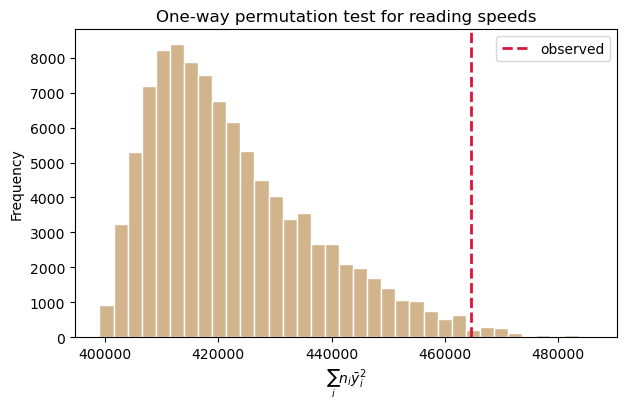

In [3]:
def one_way_statistic(groups):
    return sum(len(group) * np.mean(group) ** 2 for group in groups)


# Table 24.2: reading speeds under three typeface styles.
style1 = np.array([135, 91, 111, 87, 122], dtype=float)
style2 = np.array([175, 130, 514, 283], dtype=float)
style3 = np.array([105, 147, 159, 107, 194], dtype=float)

reading_groups = [style1, style2, style3]
reading_sizes = [len(g) for g in reading_groups]
reading_pooled = np.concatenate(reading_groups)
reading_observed = one_way_statistic(reading_groups)

B_perm = 100_000
reading_null = np.empty(B_perm)
for b in range(B_perm):
    permuted = rng.permutation(reading_pooled)
    reading_null[b] = one_way_statistic(split_by_sizes(permuted, reading_sizes))

reading_p = np.mean(reading_null >= reading_observed)
reading_se = np.sqrt(reading_p * (1 - reading_p) / B_perm)
reading_ci = (reading_p - 1.96 * reading_se, reading_p + 1.96 * reading_se)

print(f"Reading-speed permutation p-value: {reading_p:.4f}")
print(f"Approximate 95% Monte Carlo interval: ({reading_ci[0]:.4f}, {reading_ci[1]:.4f})")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(reading_null, bins=35, color="tan", edgecolor="white")
ax.axvline(reading_observed, color="crimson", linestyle="--", linewidth=2, label="observed")
ax.set_title("One-way permutation test for reading speeds")
ax.set_xlabel(r"$\sum_i n_i \bar y_i^2$")
ax.set_ylabel("Frequency")
ax.legend()
plt.show()


## 24.3 The Bootstrap

- Suppose $T(x)$ estimates a parameter or functional $t(F)$.
- In the **nonparametric bootstrap**, the data-based distribution is the empirical distribution $F_n^*$ that puts mass $1/n$ on each observed point.
- In the **parametric bootstrap**, we assume a family $F_\alpha$, estimate $\alpha$ by $\hat\alpha$, and resample from $F_{\hat\alpha}$.
- The **bootstrap correspondence principle** says that
$$
T(x) - t(F) \quad \text{and} \quad T(x^*) - t(F_n^*)
$$
should have similar distributions.
- We widen the meaning of “parameter” to include general functionals such as moments, central moments, and quantiles.
- For plug-in estimators we have the identity
$$
T(x^*) = t(F_n^*).
$$
- Moments and quantiles are plug-in estimators; the unbiased sample variance is not.


Median LSAT: 580.0
Bootstrap SE of median: 18.74
Bootstrap bias of median: 9.53
Bias-adjusted median estimate: 570.47

Correlation LSAT/GPA: 0.776
Bootstrap bias of correlation: -0.004
Bootstrap SE of correlation: 0.134


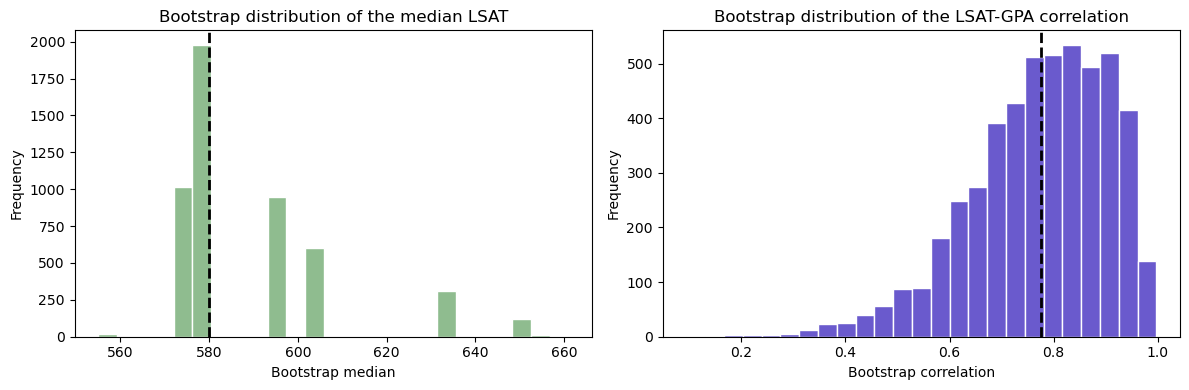

In [4]:
# Table 24.3: LSAT and GPA data from the chapter.
lsat = np.array([576, 635, 558, 578, 666, 580, 555, 661, 651, 605, 653, 575, 545, 572, 594], dtype=float)
gpa = np.array([3.39, 3.30, 2.81, 3.03, 3.44, 3.07, 3.00, 3.43, 3.36, 3.13, 3.12, 2.74, 2.76, 2.88, 2.96], dtype=float)

B_boot = 5_000
boot_idx = rng.integers(0, len(lsat), size=(B_boot, len(lsat)))
boot_lsat = lsat[boot_idx]
boot_gpa = gpa[boot_idx]

median_hat = np.median(lsat)
boot_medians = np.median(boot_lsat, axis=1)
median_se = boot_medians.std(ddof=1)
median_bias = boot_medians.mean() - median_hat
median_bias_adjusted = median_hat - median_bias

rho_hat = np.corrcoef(lsat, gpa)[0, 1]
boot_rho = np.array([np.corrcoef(xb, yb)[0, 1] for xb, yb in zip(boot_lsat, boot_gpa)])
rho_bias = boot_rho.mean() - rho_hat
rho_se = boot_rho.std(ddof=1)

print(f"Median LSAT: {median_hat:.1f}")
print(f"Bootstrap SE of median: {median_se:.2f}")
print(f"Bootstrap bias of median: {median_bias:.2f}")
print(f"Bias-adjusted median estimate: {median_bias_adjusted:.2f}")
print()
print(f"Correlation LSAT/GPA: {rho_hat:.3f}")
print(f"Bootstrap bias of correlation: {rho_bias:.3f}")
print(f"Bootstrap SE of correlation: {rho_se:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(boot_medians, bins=25, color="darkseagreen", edgecolor="white")
axes[0].axvline(median_hat, color="black", linestyle="--", linewidth=2)
axes[0].set_title("Bootstrap distribution of the median LSAT")
axes[0].set_xlabel("Bootstrap median")
axes[0].set_ylabel("Frequency")

axes[1].hist(boot_rho, bins=25, color="slateblue", edgecolor="white")
axes[1].axvline(rho_hat, color="black", linestyle="--", linewidth=2)
axes[1].set_title("Bootstrap distribution of the LSAT-GPA correlation")
axes[1].set_xlabel("Bootstrap correlation")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


### Standard Errors, Bias Reduction, and Confidence Intervals

- The bootstrap standard error is the standard deviation of the bootstrap replicates $T(x_1^*),\ldots,T(x_B^*)$.
- The bootstrap bias estimate is
$$
\widehat{\mathrm{bias}}_B^* = \frac{1}{B}\sum_{b=1}^B T(x_b^*) - T(x),
$$
and the chapter's bias-corrected estimator is
$$
T(x) - \widehat{\mathrm{bias}}_B^* = 2T(x) - \frac{1}{B}\sum_{b=1}^B T(x_b^*).
$$
- The **percentile interval** uses empirical quantiles of the bootstrap distribution.
- The **bootstrap-t interval** studentizes the statistic with an estimated variance and works best when the resulting pivot depends only weakly on $F$.
- The **BCa interval** adjusts for both median bias and skewness. Its two main ingredients are:
  - the bias-correction term $z_0 = \Phi^{-1}(\#\{\theta^* < \hat\theta\}/B)$;
  - the acceleration $a$, estimated from jackknife leave-one-out statistics.


In [5]:
percentile_ci = np.quantile(boot_medians, [0.025, 0.975])
basic_ci = 2 * median_hat - percentile_ci[::-1]
bca_result = stats.bootstrap(
    (lsat,),
    np.median,
    confidence_level=0.95,
    method="BCa",
    n_resamples=B_boot,
    random_state=rng,
).confidence_interval

jackknife_medians = np.array([np.median(np.delete(lsat, i)) for i in range(len(lsat))])
jack_bar = jackknife_medians.mean()
z0 = stats.norm.ppf(np.mean(boot_medians < median_hat))
a = -np.sum((jackknife_medians - jack_bar) ** 3) / (6 * np.sum((jackknife_medians - jack_bar) ** 2) ** 1.5)

print(f"Percentile 95% CI: ({percentile_ci[0]:.1f}, {percentile_ci[1]:.1f})")
print(f"Basic 95% CI:      ({basic_ci[0]:.1f}, {basic_ci[1]:.1f})")
print(f"BCa 95% CI:        ({bca_result.low:.1f}, {bca_result.high:.1f})")
print(f"BCa bias correction z0: {z0:.3f}")
print(f"BCa acceleration a: {a:.4f}")


Percentile 95% CI: (572.0, 651.0)
Basic 95% CI:      (509.0, 588.0)
BCa 95% CI:        (575.0, 651.0)
BCa bias correction z0: -0.265
BCa acceleration a: 0.0053


## 24.3.5 Applications in Regression

- In linear regression, bootstrap resampling can be done by resampling:
  - **cases** $(y_i, x_i)$, which is more robust to model misspecification;
  - **residuals** $r_i = y_i - \hat y_i$, which stays closer to the homoskedastic linear model.
- Residual resampling is natural when the model assumptions are believable and the design matrix should remain fixed.
- For generalized linear models, **parametric bootstrap** fits the model, then simulate new responses from the fitted conditional distributions.
- Logistic regression resamples Bernoulli responses with fitted success probabilities; Poisson regression resamples Poisson counts with fitted means.


OLS slope: 0.004523
Asymptotic slope SE: 0.001018
Case-bootstrap slope SE: 0.000856
Residual-bootstrap slope SE: 0.000959
Case-bootstrap slope CI: (0.002651, 0.005982)
Residual-bootstrap slope CI: (0.002746, 0.006471)


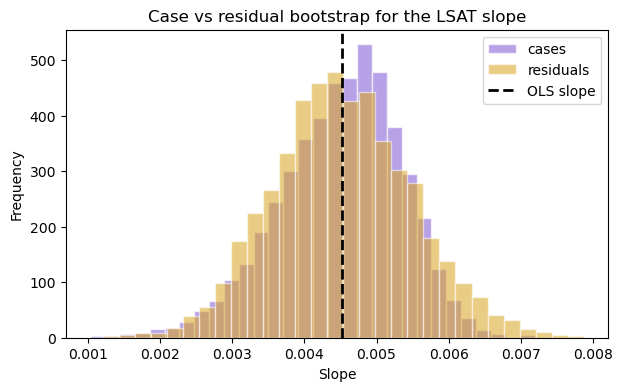

In [6]:
X = np.column_stack([np.ones(len(lsat)), lsat])
beta_hat = np.linalg.lstsq(X, gpa, rcond=None)[0]
y_hat = X @ beta_hat
residuals = gpa - y_hat

sigma2_hat = residuals @ residuals / (len(lsat) - X.shape[1])
asymptotic_cov = sigma2_hat * np.linalg.inv(X.T @ X)
asymptotic_se = np.sqrt(np.diag(asymptotic_cov))

case_beta = np.empty((B_boot, 2))
residual_beta = np.empty((B_boot, 2))

for b in range(B_boot):
    case_idx = rng.integers(0, len(lsat), size=len(lsat))
    case_beta[b] = np.linalg.lstsq(X[case_idx], gpa[case_idx], rcond=None)[0]

    resampled_residuals = rng.choice(residuals, size=len(residuals), replace=True)
    y_star = y_hat + resampled_residuals
    residual_beta[b] = np.linalg.lstsq(X, y_star, rcond=None)[0]

case_se = case_beta.std(axis=0, ddof=1)
residual_se = residual_beta.std(axis=0, ddof=1)
case_slope_ci = np.quantile(case_beta[:, 1], [0.025, 0.975])
residual_slope_ci = np.quantile(residual_beta[:, 1], [0.025, 0.975])

print(f"OLS slope: {beta_hat[1]:.6f}")
print(f"Asymptotic slope SE: {asymptotic_se[1]:.6f}")
print(f"Case-bootstrap slope SE: {case_se[1]:.6f}")
print(f"Residual-bootstrap slope SE: {residual_se[1]:.6f}")
print(f"Case-bootstrap slope CI: ({case_slope_ci[0]:.6f}, {case_slope_ci[1]:.6f})")
print(f"Residual-bootstrap slope CI: ({residual_slope_ci[0]:.6f}, {residual_slope_ci[1]:.6f})")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(case_beta[:, 1], bins=30, alpha=0.65, label="cases", color="mediumpurple", edgecolor="white")
ax.hist(residual_beta[:, 1], bins=30, alpha=0.55, label="residuals", color="goldenrod", edgecolor="white")
ax.axvline(beta_hat[1], color="black", linestyle="--", linewidth=2, label="OLS slope")
ax.set_title("Case vs residual bootstrap for the LSAT slope")
ax.set_xlabel("Slope")
ax.set_ylabel("Frequency")
ax.legend()
plt.show()


## 24.4 Efficient Bootstrap Simulations

- Ordinary bootstrap sampling adds Monte Carlo error on top of statistical uncertainty.
- The **balanced bootstrap** forces each observation to appear exactly $B$ times across the full collection of $B$ resamples. Suitable for bias estimation.
- The **antithetic bootstrap** constructs negatively correlated resamples. It is most effective for smooth statistics, especially when the statistic is a monotone function of the sample mean with modest skewness.
- **Importance resampling** samples observations with nonuniform probabilities and then reweights the resulting averages so the inferential target stays unchanged.
- These methods aim to reduce simulation error for a fixed computational budget rather than change the statistical estimand.


Sample mean: 5.200
Naive bootstrap bias estimate for the mean: 0.000450
Balanced bootstrap bias estimate for the mean: 0.000000


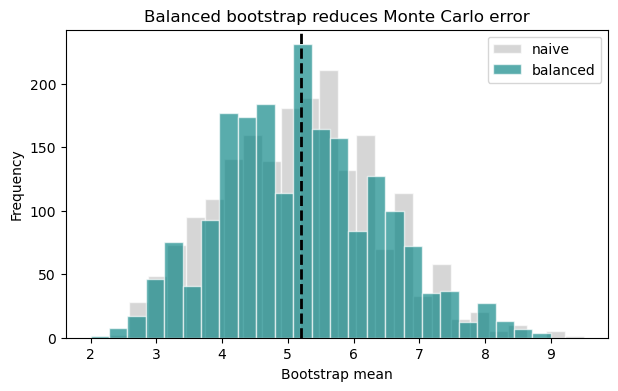

In [7]:
def balanced_bootstrap_indices(n, B, rng):
    shuffled = rng.permutation(np.repeat(np.arange(n), B))
    return shuffled.reshape(B, n)


toy = np.array([2.0, 3.5, 4.0, 7.0, 9.5])
B_balanced = 2_000
balanced_idx = balanced_bootstrap_indices(len(toy), B_balanced, rng)
naive_idx = rng.integers(0, len(toy), size=(B_balanced, len(toy)))

balanced_means = toy[balanced_idx].mean(axis=1)
naive_means = toy[naive_idx].mean(axis=1)

print(f"Sample mean: {toy.mean():.3f}")
print(f"Naive bootstrap bias estimate for the mean: {naive_means.mean() - toy.mean():.6f}")
print(f"Balanced bootstrap bias estimate for the mean: {balanced_means.mean() - toy.mean():.6f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(naive_means, bins=25, alpha=0.65, label="naive", color="silver", edgecolor="white")
ax.hist(balanced_means, bins=25, alpha=0.65, label="balanced", color="teal", edgecolor="white")
ax.axvline(toy.mean(), color="black", linestyle="--", linewidth=2)
ax.set_title("Balanced bootstrap reduces Monte Carlo error")
ax.set_xlabel("Bootstrap mean")
ax.set_ylabel("Frequency")
ax.legend()
plt.show()
